<a href="https://colab.research.google.com/github/veliveladivyasri13/PRODIGY_GA_05/blob/main/PRODIGY_GA_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from PIL import Image

In [ ]:
import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

In [ ]:
def load_img(path):
    max_dim = 512
    img = Image.open(path)
    img = img.convert('RGB')

    scale = max_dim / max(img.size)
    img = img.resize((round(img.size[0]*scale), round(img.size[1]*scale)))

    img = np.array(img).astype(np.float32) / 255.0   # ✅ FIX
    img = img[tf.newaxis, :]

    return tf.convert_to_tensor(img)

In [ ]:
from google.colab import files
uploaded = files.upload()
uploaded = files.upload()

Saving content.jpeg to content (1).jpeg


Saving style.jpeg to style (1).jpeg


In [ ]:
content_image = load_img("content.jpeg")
style_image = load_img("style.jpeg")

In [ ]:
model = hub.load(
    'https://tfhub.dev/google/magenta/arbitrary-image-stylization-v1-256/2'
)

In [ ]:
stylized_image = model(content_image, style_image)[0]

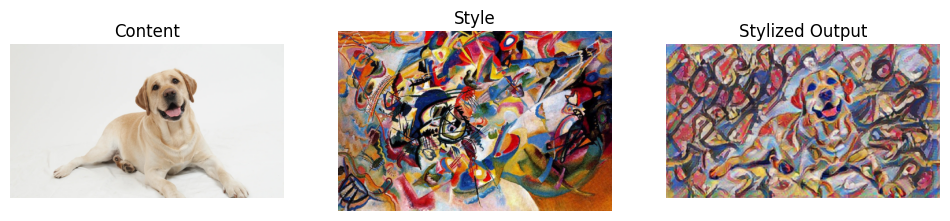

In [ ]:
def imshow(image, title=None):
    image = tf.squeeze(image, axis=0)
    plt.imshow(tf.squeeze(image))
    if title:
        plt.title(title)
    plt.axis('off')

plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
imshow(content_image, "Content")

plt.subplot(1,3,2)
imshow(style_image, "Style")

plt.subplot(1,3,3)
imshow(stylized_image, "Stylized Output")

plt.show()

In [ ]:
stylized_image = tf.squeeze(stylized_image)

image = stylized_image.numpy()
image = (image * 255).clip(0,255).astype('uint8')   # ✅ FIX

from PIL import Image
Image.fromarray(image).save("stylized_output.jpg")